In [1]:
import geopandas as gpd
import pandas as pd
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import duckdb


In [2]:
directory = '/Volumes/PhD/confinement/results/single_values/'

In [15]:
csv_files = glob(directory + '*')
for csv in csv_files[0:1]:
    df = pd.read_csv(csv, encoding="latin1",low_memory=False)

In [4]:
def get_ref_height(d, z, threshold):
    # Take all points strictly below / equal threshold
    mask = d <= threshold
    d_sub = d[mask]
    z_sub = z[mask]

    interp_at_threshold = None
    include_interpolated = True
    if include_interpolated:
        # If threshold is within the sampled distance range, interpolate between neighbors
        if d[0] <= threshold <= d[-1]:
            # Find the first index i where d[i] >= threshold
            i = np.searchsorted(d, threshold, side="left")

            if i < len(d) and d[i] == threshold:
                # Exact sample exists; interpolated value is exactly that elevation
                interp_at_threshold = z[i]
            else:
                # threshold lies between d[i-1] and d[i]
                if 0 < i < len(d):
                    d0, d1 = d[i - 1], d[i]
                    z0, z1 = z[i - 1], z[i]
                    t = (threshold - d0) / (d1 - d0)
                    interp_at_threshold = z0 + t * (z1 - z0)
                # (i==0 can't happen due to d[0] <= threshold; i==len(d) can't happen due to threshold <= d[-1])
        else:
            # If threshold is outside the range, you could extrapolate; optional.
            # Here: do NOT extrapolate outside range (common safer choice).
            interp_at_threshold = None

    # Combine elevations: all <= threshold plus optional interpolated threshold elevation
    z_candidates = z_sub.copy()
    if interp_at_threshold is not None:
        z_candidates = np.append(z_candidates, interp_at_threshold)

    # if len(z_candidates) == 0:
    #     return None, {"reason": "No points at or below threshold."}

    min_elev = float(np.min(z_candidates))

    min_elev_dict =  {
        "used_points_count": int(len(z_sub)),
        "used_distances_max": float(d_sub.max()) if len(d_sub) else None,
        "interp_at_threshold": float(interp_at_threshold) if interp_at_threshold is not None else None,
        "min_elev": min_elev,
    }
    return min_elev

In [ ]:
def get_ref_height(d, z, threshold):
    # Take all points strictly below / equal threshold
    mask = d <= threshold
    d_sub = d[mask]
    z_sub = z[mask]

    interp_at_threshold = None
    include_interpolated = True
    if include_interpolated:
        # If threshold is within the sampled distance range, interpolate between neighbors
        if d[0] <= threshold <= d[-1]:
            # Find the first index i where d[i] >= threshold
            i = np.searchsorted(d, threshold, side="left")

            if i < len(d) and d[i] == threshold:
                # Exact sample exists; interpolated value is exactly that elevation
                interp_at_threshold = z[i]
            else:
                # threshold lies between d[i-1] and d[i]
                if 0 < i < len(d):
                    d0, d1 = d[i - 1], d[i]
                    z0, z1 = z[i - 1], z[i]
                    t = (threshold - d0) / (d1 - d0)
                    interp_at_threshold = z0 + t * (z1 - z0)
                # (i==0 can't happen due to d[0] <= threshold; i==len(d) can't happen due to threshold <= d[-1])
        else:
            # If threshold is outside the range, you could extrapolate; optional.
            # Here: do NOT extrapolate outside range (common safer choice).
            interp_at_threshold = None

    # Combine elevations: all <= threshold plus optional interpolated threshold elevation
    z_candidates = z_sub.copy()
    if interp_at_threshold is not None:
        z_candidates = np.append(z_candidates, interp_at_threshold)

    # if len(z_candidates) == 0:
    #     return None, {"reason": "No points at or below threshold."}

    min_elev = float(np.min(z_candidates))

    min_elev_dict =  {
        "used_points_count": int(len(z_sub)),
        "used_distances_max": float(d_sub.max()) if len(d_sub) else None,
        "interp_at_threshold": float(interp_at_threshold) if interp_at_threshold is not None else None,
        "min_elev": min_elev,
    }
    return min_elev

def calc_area(row, H):
    w = row['bendWidths']
    areas, areas_norm = [], []
    for side in ['Inn', 'Out']:
        d = np.array(eval(row[f'dist{side}']))
        z = np.array(eval(row[f'elev{side}']))

    
        z_min = get_ref_height(d, z, w)
        dx = np.mean(np.diff(d))

        z_limit = z_min + H
        depths = np.maximum(0, z_limit - z)
        area = np.trapezoid(depths, dx=dx)
        areas_norm.append(area / (H*w))
        areas.append(area)
    return areas, areas_norm
calc_area(df.iloc[0], 15)

([np.float64(3265.4957156250603), np.float64(996.3745171875189)],
 [np.float64(5.27756883333343), np.float64(1.6103022500000306)])

In [13]:
import ast
import numpy as np

def parse_list_col(s):
    # if it's already a list/np array, return as-is
    if isinstance(s, (list, tuple, np.ndarray)):
        return np.asarray(s, dtype=np.float64)
    return np.asarray(ast.literal_eval(s), dtype=np.float64)

for side in ["Inn", "Out"]:
    df[f"dist{side}_arr"] = df[f"dist{side}"].map(parse_list_col)
    df[f"elev{side}_arr"] = df[f"elev{side}"].map(parse_list_col)

# PARQUET / DUCK approach

In [20]:
# 1) collect ids (if this list is huge, see the note below)
src = directory + "global_50_combined.parquet"

con = duckdb.connect()
cols = con.execute(f"""
    DESCRIBE SELECT * FROM '{src}'
""").fetchall()

column_names = [c[0] for c in cols]
print(column_names)

['Unnamed: 0', 'combined_reach_id', 'reach_id', 'reach_len', 'n_nodes', 'wse', 'width', 'facc', 'n_chan_max', 'n_chan_mod', 'obstr_type', 'grod_id', 'hfalls_id', 'slope', 'dist_out', 'lakeflag', 'max_width', 'n_rch_up', 'n_rch_dn', 'rch_id_up', 'rch_id_dn', 'swot_orbit', 'type', 'river_name', 'path_freq', 'path_order', 'path_segs', 'main_side', 'strm_order', 'end_reach', 'network', 'include_flag', 'pfaf1', 'pfaf2', 'localCRS', 'rch_id_up_orig', 'rch_id_dn_orig', 'n_rch_up_orig', 'n_rch_dn_orig', 'node_mean_max_width', 'dn_connected_reach', 'networkGraph', 'up_connected_reach', 'river_segment', 'river_segment_order', 'reach_order', 'dn_river_segment', 'combined_reach_len', 'combined_reach_width', 'combined_reach_max_width', 'networkGroup', 'max_dist_out', 'up_reach_id', 'catchment_position', 'combined_reach_up', 'combined_reach_dn', 'geometry', 'combined_reach_crs', 'widthRatio', 'sin', 'bendSin', 'apex', 'apexP', 'ang', 'infP', 'bendLines', 'bendWidths', 'bendMaxWidths', 'bendDistOut',

In [28]:
cid = 'af_00_0'
B = duckdb.sql(f"""
  SELECT bendWidths, global_id, continent, continent_id, bendDistOut, combined_reach_id, distOut
  FROM read_parquet('{src}')
  WHERE global_id = '{cid}'
""").df()
len(B.iloc[0]['distOut'])
B

,bendWidths,global_id,continent,continent_id,bendDistOut,combined_reach_id,distOut
0,37.2,af_00_0,af,00,1.466656e+06,0.0,"[0.0, 4.650000000025921, 9.300000000051842, 13..."


In [22]:
duckdb.sql(f"""
    COPY (
        SELECT *
        FROM '{src}'
        LIMIT 100
    )
    TO 'output.csv'
    (HEADER, DELIMITER ',');
""")

In [19]:
import duckdb
import numpy as np
import numba as nb
import pyarrow as pa
import pyarrow.parquet as pq

typed_parquet = directory + "global_50_combined_typed_arrays.parquet"
out_parquet   = directory + "global_50_combined_areas.parquet"

Hs = np.array([5.0, 10.0, 15.0, 20.0, 25, 30,40,50], dtype=np.float64)

batch_size = 20_000     # increase later if RAM allows
limit_rows = 100000       # set None for full run


# -----------------------------
# Arrow helper: LIST<DOUBLE> -> 2D array
# -----------------------------
def listcol_to_2d(col: pa.Array, L: int | None = None):
    """
    Convert Arrow list<double> column to:
      out: (nrows, L) float64 (nan-filled)
      keep: (nrows,) bool for rows that are valid AND have length L
      L: detected/used length
    """
    if isinstance(col, pa.ChunkedArray):
        arr = col.combine_chunks()
    else:
        arr = col

    n = len(arr)
    valid = np.asarray(arr.is_valid().to_numpy(zero_copy_only=False), dtype=bool)

    # offsets length n+1
    offsets = np.asarray(arr.offsets.to_numpy(zero_copy_only=False), dtype=np.int64)
    lengths = offsets[1:] - offsets[:-1]

    # infer L from first valid row if needed
    if L is None:
        idxs = np.where(valid)[0]
        if idxs.size == 0:
            return np.full((n, 0), np.nan), np.zeros(n, dtype=bool), 0
        L = int(lengths[idxs[0]])

    keep = valid & (lengths == L)

    flat = np.asarray(arr.values.to_numpy(zero_copy_only=False), dtype=np.float64)

    out = np.full((n, L), np.nan, dtype=np.float64)
    kept_rows = np.where(keep)[0]
    if kept_rows.size:
        starts = offsets[kept_rows]
        idx = starts[:, None] + np.arange(L, dtype=np.int64)[None, :]
        out[kept_rows, :] = flat[idx]

    return out, keep, L


# -----------------------------
# Numba kernels
# -----------------------------
@nb.njit
def ref_height_1d(d, z, w):
    n = d.size
    if n == 0:
        return np.nan

    m = 1e308
    any_le = False
    for i in range(n):
        if d[i] <= w:
            any_le = True
            zi = z[i]
            if zi < m:
                m = zi

    interp = 1e308
    if d[0] <= w <= d[n - 1]:
        i = np.searchsorted(d, w, side="left")
        if i < n and d[i] == w:
            interp = z[i]
        elif 0 < i < n:
            d0, d1 = d[i - 1], d[i]
            z0, z1 = z[i - 1], z[i]
            t = (w - d0) / (d1 - d0)
            interp = z0 + t * (z1 - z0)

    if any_le:
        return m if m < interp else interp
    else:
        return interp


@nb.njit
def trapezoid_depths(depths, dx):
    s = 0.0
    for i in range(depths.size - 1):
        s += 0.5 * (depths[i] + depths[i + 1]) * dx
    return s


@nb.njit
def compute_manyH_for_batch(D, Z, W, keep, Hs):
    nrows, L = D.shape
    nH = Hs.size

    areas = np.full((nrows, nH), np.nan, dtype=np.float64)
    norms = np.full((nrows, nH), np.nan, dtype=np.float64)

    depths = np.empty(L, dtype=np.float64)

    for r in range(nrows):
        if not keep[r]:
            continue
        if L < 2:
            continue

        d = D[r]
        z = Z[r]
        w = W[r]

        zmin = ref_height_1d(d, z, w)
        dx = (d[L - 1] - d[0]) / (L - 1)

        for j in range(nH):
            H = Hs[j]
            zlim = zmin + H

            for i in range(L):
                v = zlim - z[i]
                depths[i] = v if v > 0.0 else 0.0

            area = trapezoid_depths(depths, dx)
            areas[r, j] = area
            norms[r, j] = area / (H * w) if (H != 0.0 and w != 0.0) else np.nan

    return areas, norms


# -----------------------------
# Read -> compute -> write
# -----------------------------
con = duckdb.connect()
limit_sql = f"LIMIT {int(limit_rows)}" if limit_rows is not None else ""

query = f"""
SELECT
  bendWidths,
  distInn_arr, elevInn_arr,
  distOut_arr, elevOut_arr
FROM read_parquet('{typed_parquet}')
{limit_sql}
"""

cur = con.execute(query)

# IMPORTANT: this returns a RecordBatchReader in your environment
reader = cur.fetch_record_batch(batch_size)

writer = None
total = 0
L_inn = None
L_out = None

for batch in reader:
    nrows = batch.num_rows
    total += nrows

    W = np.asarray(batch.column("bendWidths").to_numpy(zero_copy_only=False), dtype=np.float64)

    D_inn, keep_d_inn, L_inn = listcol_to_2d(batch.column("distInn_arr"), L=L_inn)
    Z_inn, keep_z_inn, _     = listcol_to_2d(batch.column("elevInn_arr"), L=L_inn)
    keep_inn = keep_d_inn & keep_z_inn

    D_out, keep_d_out, L_out = listcol_to_2d(batch.column("distOut_arr"), L=L_out)
    Z_out, keep_z_out, _     = listcol_to_2d(batch.column("elevOut_arr"), L=L_out)
    keep_out = keep_d_out & keep_z_out

    a_inn, n_inn = compute_manyH_for_batch(D_inn, Z_inn, W, keep_inn, Hs)
    a_out, n_out = compute_manyH_for_batch(D_out, Z_out, W, keep_out, Hs)

    cols = {"bendWidths": pa.array(W, type=pa.float64())}
    for j, H in enumerate(Hs):
        Hj = int(H) if float(H).is_integer() else H
        cols[f"area_Inn_H{Hj}"] = pa.array(a_inn[:, j], type=pa.float64())
        cols[f"areaNorm_Inn_H{Hj}"] = pa.array(n_inn[:, j], type=pa.float64())
        cols[f"area_Out_H{Hj}"] = pa.array(a_out[:, j], type=pa.float64())
        cols[f"areaNorm_Out_H{Hj}"] = pa.array(n_out[:, j], type=pa.float64())

    out_table = pa.Table.from_pydict(cols)

    if writer is None:
        writer = pq.ParquetWriter(out_parquet, out_table.schema, compression="zstd")
    writer.write_table(out_table)

if writer is not None:
    writer.close()

print("Wrote:", out_parquet)
print("Rows processed:", total)
print("Detected list lengths:", {"Inn": L_inn, "Out": L_out})


Wrote: /Volumes/PhD/confinement/results/single_values/global_50_combined_areas.parquet
Rows processed: 100000
Detected list lengths: {'Inn': 400, 'Out': 400}


In [25]:
out_parquet   = directory + "global_50_combined_areas.parquet"
# 1) read only what you need (first 1000 rows)
df = duckdb.sql(f"""
  SELECT bendWidths, COLUMNS('area*')
  FROM read_parquet('{out_parquet}')
  LIMIT 10000
""").df()

In [24]:
df.columns

Index(['bendWidths', 'area_Inn_H5', 'areaNorm_Inn_H5', 'area_Out_H5',
       'areaNorm_Out_H5', 'area_Inn_H10', 'areaNorm_Inn_H10', 'area_Out_H10',
       'areaNorm_Out_H10', 'area_Inn_H15', 'areaNorm_Inn_H15', 'area_Out_H15',
       'areaNorm_Out_H15', 'area_Inn_H20', 'areaNorm_Inn_H20', 'area_Out_H20',
       'areaNorm_Out_H20', 'area_Inn_H25', 'areaNorm_Inn_H25', 'area_Out_H25',
       'areaNorm_Out_H25', 'area_Inn_H30', 'areaNorm_Inn_H30', 'area_Out_H30',
       'areaNorm_Out_H30', 'area_Inn_H40', 'areaNorm_Inn_H40', 'area_Out_H40',
       'areaNorm_Out_H40', 'area_Inn_H50', 'areaNorm_Inn_H50', 'area_Out_H50',
       'areaNorm_Out_H50'],
      dtype='object')

In [6]:
parquet_path = "your_file.parquet"  # <-- change this
src =  directory + "global_50_combined.parquet"

In [7]:
import duckdb

parquet_path = src              # your input parquet path
out_path = "areas_H15.parquet"  # output parquet
H = 15.0

con = duckdb.connect()
con.execute("SET threads TO 8")  # adjust if you want

def try_sql(sql: str) -> bool:
    try:
        con.execute(sql)
        return True
    except Exception:
        return False

# Pick parquet reader available in your build
if try_sql(f"SELECT 1 FROM parquet_scan('{parquet_path}') LIMIT 1"):
    parquet_from = f"parquet_scan('{parquet_path}')"
elif try_sql(f"SELECT 1 FROM read_parquet('{parquet_path}') LIMIT 1"):
    parquet_from = f"read_parquet('{parquet_path}')"
else:
    raise RuntimeError("Neither parquet_scan() nor read_parquet() works in this DuckDB build.")

# Prefer list_sum/list_min if available (avoids list_reduce lambda issues)
has_list_sum = try_sql("SELECT list_sum([1.0,2.0,3.0])")
has_list_min = try_sql("SELECT list_min([3.0,2.0,1.0])")

if not (has_list_sum and has_list_min):
    raise RuntimeError(
        "Your DuckDB build lacks list_sum/list_min. "
        "Paste `SELECT version();` and I’ll give the compatible fallback."
    )

# Optional: test on a subset first (recommended)
# limit_clause = "LIMIT 10000"
limit_clause = ""

query = f"""
COPY (
WITH src AS (
  SELECT global_id, bendWidths, distInn, elevInn, distOut, elevOut
  FROM {parquet_from}
  {limit_clause}
)

SELECT
  s.global_id,
  inn.area AS area_inn,
  outt.area AS area_out
FROM src s

-- ----------------
-- Inn side (no UNNEST)
-- ----------------
CROSS JOIN LATERAL (
  WITH
    base AS (
      SELECT
        s.distInn AS d,
        s.elevInn AS z,
        s.bendWidths::DOUBLE AS w,
        {H}::DOUBLE AS H,
        len(s.distInn) AS n
    ),
    exact AS (
      SELECT
        *,
        list_position(d, w) AS pos_exact,
        CASE WHEN list_position(d, w) IS NULL THEN NULL ELSE z[list_position(d, w)] END AS z_exact
      FROM base
    ),
    seg AS (
      SELECT
        *,
        list_extract(
          list_filter(range(1, n), i -> (d[i] < w) AND (w < d[i + 1])),
          1
        ) AS i_seg
      FROM exact
    ),
    ref AS (
      SELECT
        *,
        CASE
          WHEN i_seg IS NULL THEN NULL
          ELSE z[i_seg] + ((w - d[i_seg]) / (d[i_seg + 1] - d[i_seg])) * (z[i_seg + 1] - z[i_seg])
        END AS z_interp,

        list_transform(
          list_filter(range(1, n + 1), i -> d[i] <= w),
          i -> z[i]
        ) AS z_le
      FROM seg
    ),
    zmin AS (
      SELECT
        *,
        CASE WHEN len(z_le) = 0 THEN NULL ELSE list_min(z_le) END AS z_min_le,
        CASE
          WHEN (CASE WHEN len(z_le) = 0 THEN NULL ELSE list_min(z_le) END) IS NULL
               AND z_exact IS NULL
               AND z_interp IS NULL
            THEN NULL
          ELSE least(
            coalesce((CASE WHEN len(z_le) = 0 THEN NULL ELSE list_min(z_le) END), 1.0e308),
            coalesce(z_exact, z_interp, 1.0e308)
          )
        END AS z_min
      FROM ref
    )
  SELECT
    CASE
      WHEN z_min IS NULL THEN NULL
      ELSE
        list_sum(
          list_transform(
            range(1, n),
            i -> (
              (
                greatest(0.0, (z_min + H) - z[i]) +
                greatest(0.0, (z_min + H) - z[i + 1])
              ) / 2.0
            ) * (d[i + 1] - d[i])
          )
        )
    END AS area
  FROM zmin
) inn

-- ----------------
-- Out side (no UNNEST)
-- ----------------
CROSS JOIN LATERAL (
  WITH
    base AS (
      SELECT
        s.distOut AS d,
        s.elevOut AS z,
        s.bendWidths::DOUBLE AS w,
        {H}::DOUBLE AS H,
        len(s.distOut) AS n
    ),
    exact AS (
      SELECT
        *,
        list_position(d, w) AS pos_exact,
        CASE WHEN list_position(d, w) IS NULL THEN NULL ELSE z[list_position(d, w)] END AS z_exact
      FROM base
    ),
    seg AS (
      SELECT
        *,
        list_extract(
          list_filter(range(1, n), i -> (d[i] < w) AND (w < d[i + 1])),
          1
        ) AS i_seg
      FROM exact
    ),
    ref AS (
      SELECT
        *,
        CASE
          WHEN i_seg IS NULL THEN NULL
          ELSE z[i_seg] + ((w - d[i_seg]) / (d[i_seg + 1] - d[i_seg])) * (z[i_seg + 1] - z[i_seg])
        END AS z_interp,

        list_transform(
          list_filter(range(1, n + 1), i -> d[i] <= w),
          i -> z[i]
        ) AS z_le
      FROM seg
    ),
    zmin AS (
      SELECT
        *,
        CASE WHEN len(z_le) = 0 THEN NULL ELSE list_min(z_le) END AS z_min_le,
        CASE
          WHEN (CASE WHEN len(z_le) = 0 THEN NULL ELSE list_min(z_le) END) IS NULL
               AND z_exact IS NULL
               AND z_interp IS NULL
            THEN NULL
          ELSE least(
            coalesce((CASE WHEN len(z_le) = 0 THEN NULL ELSE list_min(z_le) END), 1.0e308),
            coalesce(z_exact, z_interp, 1.0e308)
          )
        END AS z_min
      FROM ref
    )
  SELECT
    CASE
      WHEN z_min IS NULL THEN NULL
      ELSE
        list_sum(
          list_transform(
            range(1, n),
            i -> (
              (
                greatest(0.0, (z_min + H) - z[i]) +
                greatest(0.0, (z_min + H) - z[i + 1])
              ) / 2.0
            ) * (d[i + 1] - d[i])
          )
        )
    END AS area
  FROM zmin
) outt
) TO '{out_path}' (FORMAT PARQUET);
"""

con.execute(query)
print("Wrote:", out_path)


: 

In [25]:
df

,bendWidths,global_id,continent,continent_id,bendDistOut,combined_reach_id
0,37.200000,af_00_0,af,00,1.466656e+06,0.0
1,44.625000,af_00_1,af,00,1.467620e+06,0.0
2,45.250000,af_00_2,af,00,1.468919e+06,0.0
3,40.350000,af_00_3,af,00,1.470125e+06,0.0
4,39.857143,af_00_4,af,00,1.472452e+06,0.0
...,...,...,...,...,...,...
1490568,24.000000,sa_04_33329,sa,04,2.568690e+05,26752.0
1490569,24.000000,sa_04_33330,sa,04,2.570852e+05,26752.0
1490570,24.000000,sa_04_33331,sa,04,2.573082e+05,26752.0
1490571,31.500000,sa_04_33332,sa,04,2.579772e+05,26752.0


In [18]:
out_parquet   = directory + "areas_multiH.parquet"
# 1) read only what you need (first 1000 rows)
df = duckdb.sql(f"""
  SELECT *
  FROM read_parquet('{out_parquet}')
  LIMIT 1000
""").df()
df.head()

,global_id,area_inn_H5_0,area_out_H5_0,W_inn_H5_0,W_out_H5_0,area_inn_H10_0,area_out_H10_0,W_inn_H10_0,W_out_H10_0,area_inn_H15_0,...,W_inn_H40_0,W_out_H40_0,area_inn_H45_0,area_out_H45_0,W_inn_H45_0,W_out_H45_0,area_inn_H50_0,area_out_H50_0,W_inn_H50_0,W_out_H50_0
0,af_00_0,548.932779,175.677000,125.550000,14.731448,1451.884380,1127.694053,231.105190,388.533333,3213.121309,...,1592.580069,1792.679073,41052.380896,43574.862560,1743.248928,NaN,50124.485419,52851.612560,NaN,NaN
1,af_00_1,84.601748,125.507813,19.921892,25.146913,978.274995,252.410156,500.205241,37.054687,3936.020274,...,NaN,643.947969,52558.717933,16934.641513,NaN,672.626025,63687.077308,20366.844533,NaN,709.358179
2,af_00_2,2648.269599,311.093750,664.196356,13.013386,6505.097635,698.690261,846.227013,136.027262,11352.198277,...,NaN,NaN,74194.116826,46853.219265,NaN,NaN,85478.335576,58137.438015,NaN,NaN
3,af_00_3,315.234375,12.609375,65.135375,3.296526,1960.691084,339.154107,491.867912,192.533393,5391.006438,...,NaN,NaN,54310.808824,42445.257476,NaN,NaN,64373.090074,52507.538726,NaN,NaN
4,af_00_4,218.466964,236.651786,56.117235,49.248184,1212.159293,1002.056201,504.858896,226.554074,4610.892653,...,1978.203782,1334.550415,50926.582247,25277.550112,NaN,1964.049585,60865.957247,35207.300559,NaN,NaN


In [23]:
df['diffH'] = df['W_out_H5_0'] / df['W_out_H50_0']
df['diffA'] = df['area_out_H5_0'] / df['area_out_H50_0']

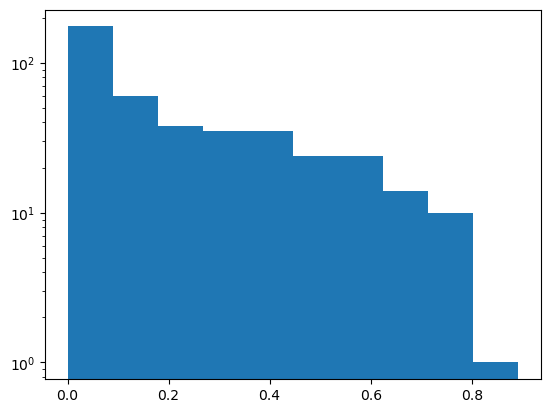

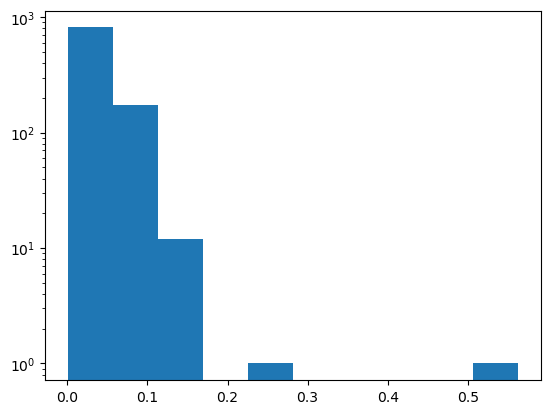

In [24]:
plt.figure()
plt.hist(df['diffH'])
plt.yscale('log')
plt.figure()
plt.hist(df['diffA'])
plt.yscale('log')